In [1]:
import os
import pandas as pd

In [2]:
def get_csv_file_info(folder_path):
    """
    Go through each CSV file in a folder and return a DataFrame with file paths and row counts.
    
    Parameters:
    -----------
    folder_path : str
        Path to the folder containing CSV files
        
    Returns:
    --------
    pd.DataFrame
        DataFrame with two columns:
        - col1: file path (relative or absolute)
        - col2: row count
    """
    import glob
    import csv
    
    csv_files = glob.glob(os.path.join(folder_path, "*.csv"))
    file_info = []
    
    for csv_file in csv_files:
        try:
            # Count rows properly handling CSV format (quoted fields with newlines)
            with open(csv_file, 'r', encoding='utf-8') as f:
                reader = csv.reader(f)
                row_count = sum(1 for row in reader) - 1  # Subtract 1 for header
            file_info.append({
                'col1': csv_file,
                'col2': row_count
            })
        except Exception as e:
            print(f"Error reading {csv_file}: {e}")
            file_info.append({
                'col1': csv_file,
                'col2': 0
            })
    
    # Create DataFrame
    result_df = pd.DataFrame(file_info)
    return result_df.sort_values(by='col2', ascending=False).reset_index(drop=True)

# run func
folder_path = "../data/raw/13998/v35_data_processing"
csv_info_df = get_csv_file_info(folder_path)
csv_info_df


,col1,col2
0,../data/raw/13998/v35_data_processing/s71_bt1x...,233479
1,../data/raw/13998/v35_data_processing/we3_bt1x...,208903
2,../data/raw/13998/v35_data_processing/we1_bt1x...,208903
3,../data/raw/13998/v35_data_processing/eb1_bt1x...,201735
4,../data/raw/13998/v35_data_processing/eb3_bt1x...,201735
5,../data/raw/13998/v35_data_processing/vm1_bt1x...,180231
6,../data/raw/13998/v35_data_processing/vm3_bt1x...,180231
7,../data/raw/13998/v35_data_processing/eg3_bt1x...,141319
8,../data/raw/13998/v35_data_processing/xf3_bt1x...,137223
9,../data/raw/13998/v35_data_processing/xf1_bt1x...,137223


In [3]:
"""CSV file parsing with header detection."""

import io
import logging
import os
from dataclasses import dataclass, field

import pandas as pd

logger = logging.getLogger(__name__)


@dataclass
class ParsedFile:
    """Result of parsing a CSV file."""

    filename: str
    dataframe: pd.DataFrame
    headers: list[str] = field(default_factory=list)
    units: list[str] = field(default_factory=list)
    is_valid: bool = True
    error: str | None = None
    row_count: int = 0


class CSVParser:
    """
    Parse CSV files with specialized header detection.

    Handles RSP-format CSV files with metadata rows:
    - #HEADER
    - #TITLES (column names)
    - #UNITS
    - #DATATYPES
    - #DATA (actual data starts here)
    """

    # Known metadata markers
    MARKERS = {"#HEADER", "#TITLES", "#UNITS", "#DATATYPES", "#DATA"}

    def parse(self, filepath: str) -> ParsedFile:
        """
        Parse CSV file from filepath and return ParsedFile.

        Args:
            filepath: Path to the CSV file

        Returns:
            ParsedFile with DataFrame and metadata
        """
        filename = os.path.basename(filepath)
        try:
            # Read file content
            with open(filepath, 'r', encoding='utf-8', errors='replace') as f:
                text = f.read()
            
            lines = text.strip().split("\n")

            # Find data start and extract metadata
            data_start_idx = 0
            headers: list[str] = []
            units: list[str] = []

            for i, line in enumerate(lines):
                stripped = line.strip()
                if stripped == "#DATA":
                    data_start_idx = i + 1
                    break
                elif stripped == "#TITLES" and i + 1 < len(lines):
                    # Next line contains headers
                    header_line = lines[i + 1]
                    headers = [h.strip() for h in header_line.split(",")]
                elif stripped == "#UNITS" and i + 1 < len(lines):
                    # Next line contains units
                    unit_line = lines[i + 1]
                    units = [u.strip() for u in unit_line.split(",")]

            # If no #DATA marker found, assume data starts at first non-marker line
            if data_start_idx == 0:
                for i, line in enumerate(lines):
                    stripped = line.strip()
                    if stripped and not stripped.startswith("#"):
                        # Check if this looks like a header row
                        if i == 0 or not any(c.isdigit() for c in stripped.split(",")[0]):
                            headers = [h.strip() for h in stripped.split(",")]
                            data_start_idx = i + 1
                        else:
                            data_start_idx = i
                        break

            # Parse data section
            data_text = "\n".join(lines[data_start_idx:])
            df = pd.read_csv(
                io.StringIO(data_text),
                header=None,
                dtype=float,
                on_bad_lines="warn",
            )

            # Assign headers if we have them and they match column count
            if headers and len(headers) == len(df.columns):
                df.columns = headers
            elif headers:
                # Pad or truncate headers to match column count
                if len(headers) < len(df.columns):
                    headers.extend([f"col_{i}" for i in range(len(headers), len(df.columns))])
                df.columns = headers[: len(df.columns)]

            logger.info(f"Parsed {filename}: {len(df)} rows, {len(df.columns)} columns")

            return ParsedFile(
                filename=filename,
                dataframe=df,
                headers=list(df.columns),
                units=units,
                is_valid=True,
                row_count=len(df),
            )

        except Exception as e:
            logger.error(f"Failed to parse {filename}: {e}")
            return ParsedFile(
                filename=filename,
                dataframe=pd.DataFrame(),
                is_valid=False,
                error=str(e),
            )

In [4]:
parser = CSVParser()
csv_file = csv_info_df.iloc[0]['col1']
parsed = parser.parse(csv_file)
df = parsed.dataframe
df

,,,001_1 LF LCA OtrBJ P_UG_X Force,002_2 LF LCA OtrBJ P_UG_Y Force,003_3 LF LCA OtrBJ P_UG_Z Force,004_4 LF ShockLwBsh P_UG_X Force,005_5 LF ShockLwBsh P_UG_Y Force,006_6 LF ShockLwBsh P_UG_Z Force,007_7 LF LCABushingF P_UG_X Force,008_8 LF LCABushingF P_UG_Y Force,...,012_12 LF LCABushingR P_UG_Z Force,013_13 LF ShockLwBsh P_UG_X Momt,014_14 LF ShockLwBsh P_UG_Y Momt,015_15 LF ShockLwBsh P_UG_Z Momt,016_16 LF LCABushingF P_UG_X Momt,017_17 LF LCABushingF P_UG_Y Momt,018_18 LF LCABushingF P_UG_Z Momt,019_19 LF LCABushingR P_UG_X Momt,020_20 LF LCABushingR P_UG_Y Momt,021_21 LF LCABushingR P_UG_Z Momt
0,1.0,0.000,0.00,0.0,0.0,0.00,0.0,0.0,0.00,0.0,...,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0
1,2.0,0.001,-99.62,548.5,4277.0,10.79,-2048.0,-6572.0,-25.15,217.2,...,976.5,422.4,-1180.0,903.6,-74.61,-2441.0,675.0,-376.8,584.0,-323.7
2,3.0,0.002,292.70,-279.9,8756.0,40.43,-3599.0,-11550.0,-64.96,1181.0,...,2632.0,1427.0,189.5,1307.0,-1086.00,896.1,2037.0,-863.5,7368.0,-1424.0
3,4.0,0.003,282.40,-1532.0,9970.0,21.06,-4390.0,-13320.0,-147.20,2008.0,...,2886.0,461.5,-1894.0,1520.0,-1553.00,-2041.0,2486.0,-1103.0,6197.0,-1968.0
4,5.0,0.004,372.30,-2833.0,8234.0,-35.63,-4074.0,-11670.0,-229.00,2504.0,...,2422.0,-1689.0,-3700.0,1132.0,-1083.00,-1854.0,3123.0,-1331.0,1504.0,-3324.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
233467,233468.0,233.467,303.30,-2849.0,9446.0,67.50,-3974.0,-12910.0,-264.00,2446.0,...,2623.0,20370.0,-2268.0,-542.4,4343.00,-1383.0,2310.0,5853.0,4359.0,-3008.0
233468,233469.0,233.468,303.30,-2849.0,9446.0,67.50,-3974.0,-12910.0,-264.00,2446.0,...,2623.0,20370.0,-2268.0,-542.4,4343.00,-1383.0,2310.0,5853.0,4359.0,-3008.0
233469,233470.0,233.469,303.30,-2849.0,9446.0,67.50,-3974.0,-12910.0,-264.00,2446.0,...,2623.0,20370.0,-2268.0,-542.4,4343.00,-1383.0,2310.0,5853.0,4359.0,-3008.0
233470,233471.0,233.470,303.30,-2849.0,9446.0,67.50,-3974.0,-12910.0,-264.00,2446.0,...,2623.0,20370.0,-2268.0,-542.4,4343.00,-1383.0,2310.0,5853.0,4359.0,-3008.0


In [6]:
def get_event(df,cols=[2,3]):
    """
    Get event data from a DataFrame.
    
    Args:
        df: DataFrame
        cols: list of column indices to get
        
    Returns:
        Tuple consisting of all rows in col 2 and all rows in col 3
    """ 
    col2 = df.iloc[:, cols[0]].to_numpy()
    col3 = df.iloc[:, cols[1]].to_numpy()
    return (col2, col3)

raw_event = get_event(df)
x=raw_event[0]
y=raw_event[1]
x

array([  0.  , -99.62, 292.7 , ..., 303.3 , 303.3 , 303.3 ])

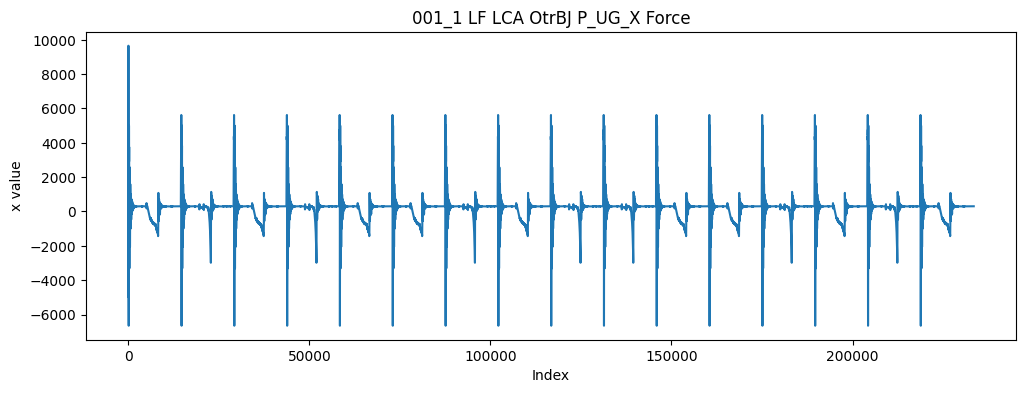

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.plot(x)
plt.title('001_1 LF LCA OtrBJ P_UG_X Force')
plt.xlabel('Index')
plt.ylabel('x value')
plt.show()

In [15]:
import py_fatigue as pf
import numpy as np

s = x
t = np.arange(len(s))

In [35]:
# CycleCount definition
cycle_count = pf.CycleCount.from_timeseries(
    time=t, data=s, mean_bin_width=100., range_bin_width=100.,
)
cycle_count

,None
Cycle counting object,
"largest full stress range, MPa",12272.0
"largest stress range, MPa",16306.0
number of full cycles,6873
number of residuals,34
number of small cycles,0
stress concentration factor,N/A
residuals resolved,False
mean stress-corrected,No


In [36]:
# Exporting the cycle-count matrix in the legacy format, i.e. not
# accounting for mean stresses. This function has been kept for
# backwards compatibility.
exp_dict_legacy = cycle_count.as_dict(
    max_consecutive_zeros=20, damage_tolerance_for_binning=0.2
)
print(exp_dict_legacy)

{'nr_small_cycles': 44, 'range_bin_lower_bound': 0.2, 'range_bin_width': 100.0, 'mean_bin_lower_bound': -2850.0, 'mean_bin_width': 100.0, 'hist': [[0.0, 0.0, 0.0, 0.0, 16.0], [], [], [], [], [], [], [], [], [], [], [], [], [], [9.0], [108.0], [108.0], [90.0], [63.0], [162.0], [234.0], [594.0], [171.0], [72.0, 9.0], [207.0], [72.0], [27.0], [18.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 16.0], [44.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 16.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 8.0], [263.0, 7.0, 7.0, 0.0, 0.0, 0.0, 8.0, 16.0], [4221.0, 38.0, 31.0, 31.0, 16.0, 0.0, 0.0, 0.0, 0.0, 8.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 15.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 7.0, 0.0, 0.0, 7.0], [], [0.0, 1.0], [9.0], [], [1.0], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 16.0], [], [], [], [

In [37]:
# Exporting the cycle-count matrix
exp_dict = cycle_count.as_dict(
    max_consecutive_zeros=20, damage_tolerance_for_binning=1
)
print(exp_dict)

{'nr_small_cycles': 44, 'range_bin_lower_bound': 0.2, 'range_bin_width': 100.0, 'mean_bin_lower_bound': -2850.0, 'mean_bin_width': 100.0, 'hist': [[0.0, 0.0, 0.0, 0.0, 16.0], [], [], [], [], [], [], [], [], [], [], [], [], [], [9.0], [108.0], [108.0], [90.0], [63.0], [162.0], [234.0], [594.0], [171.0], [72.0, 9.0], [207.0], [72.0], [27.0], [18.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 16.0], [44.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 16.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 8.0], [263.0, 7.0, 7.0, 0.0, 0.0, 0.0, 8.0, 16.0], [4221.0, 38.0, 31.0, 31.0, 16.0, 0.0, 0.0, 0.0, 0.0, 8.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 15.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 7.0, 0.0, 0.0, 7.0], [], [0.0, 1.0], [9.0], [], [1.0], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 16.0], [], [], [], [

In [38]:
# Reconstructing the CycleCount instance from the exported matrix
cycle_count_d = pf.CycleCount.from_rainflow(exp_dict, name="Random Signal")
cycle_count_d

,Random Signal
Cycle counting object,
"largest full stress range, MPa",12272.0
"largest stress range, MPa",16306.0
number of full cycles,6829
number of residuals,34
number of small cycles,44
stress concentration factor,N/A
residuals resolved,False
mean stress-corrected,No


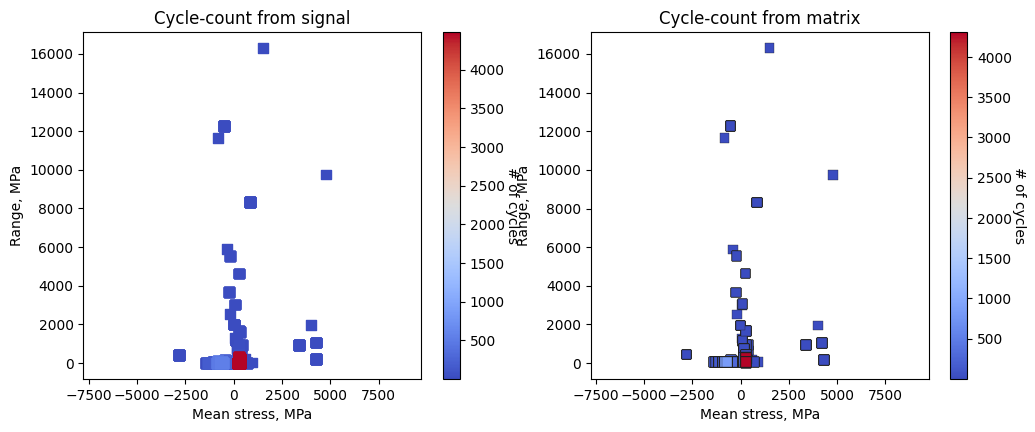

In [39]:
import matplotlib as mpl
import matplotlib.pyplot as plt
fig, axs = plt.subplots(1, 2, figsize=(12, 4.5))
cycle_count.plot_histogram(
    fig=fig, ax=axs[0], plot_type="mean-range",
    marker="s", s=50, cmap=mpl.colormaps["coolwarm"]
)
axs[0].set_title("Cycle-count from signal")
cycle_count_d.plot_histogram(
    fig=fig, ax=axs[1], plot_type="mean-range",
    marker="s", s=50, edgecolors="#222",
    cmap=mpl.colormaps["coolwarm"], linewidth=0.25
)
axs[1].set_title("Cycle-count from matrix")
plt.show()

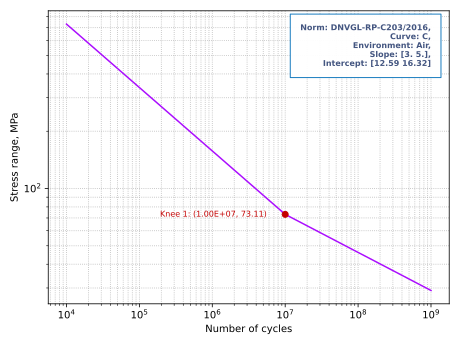

In [40]:
c_air = pf.SNCurve(
    [3, 5],
    intercept=[12.592, 16.320],
    norm="DNVGL-RP-C203/2016",
    environment='Air',
    curve='C'
)
c_air

In [41]:
# Calculate damage for the cycle-count objects
damage = pf.damage.stress_life.get_pm(cycle_count=cycle_count, sn_curve=c_air)
damage_d = pf.damage.stress_life.get_pm(cycle_count=cycle_count_d, sn_curve=c_air)
print(f"damage from signal: {sum(damage)}")
print(f"damage from matrix: {sum(damage_d)}")

damage from signal: 11.025489782275695
damage from matrix: 11.02569154105936
